In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv("data/processed/df_clean_with_all_features_model_ready_2010_2024.csv")
df["date"] = pd.to_datetime(df["date"])
# Only include date from 2010 - 2024
df = df[(df["date"] >= "2010-01-01") & (df["date"] <= "2024-12-31")]


We will be visualizing the features that may be correlated with ZHVI using scatterplot and heapmap.
Features: division, date, hpi, unemployment_rate, total_population, median_income, bachelors_pct,total_households, construction_permits, rental_vacancy_rate

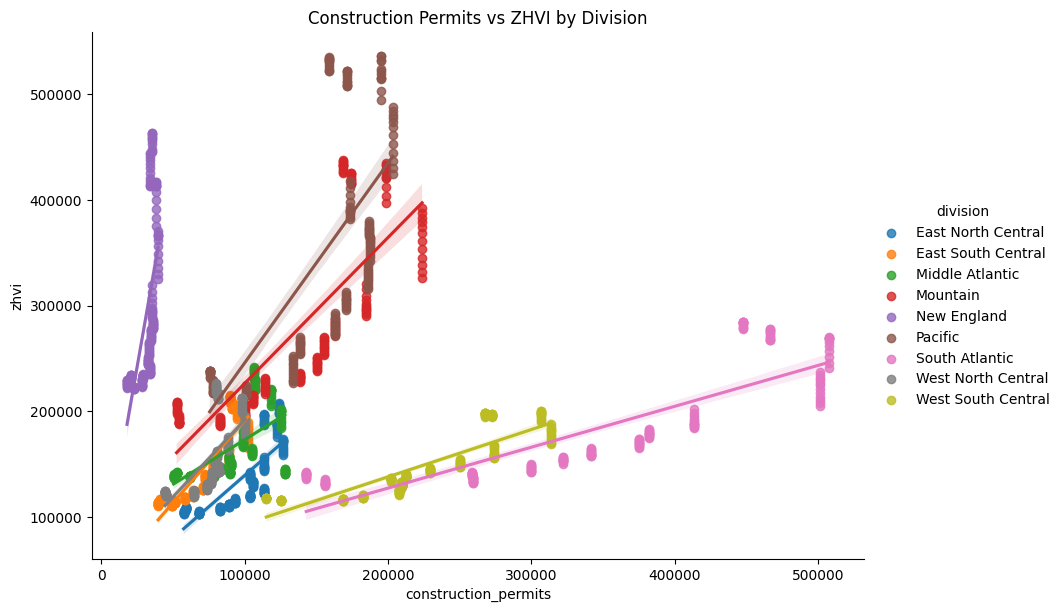

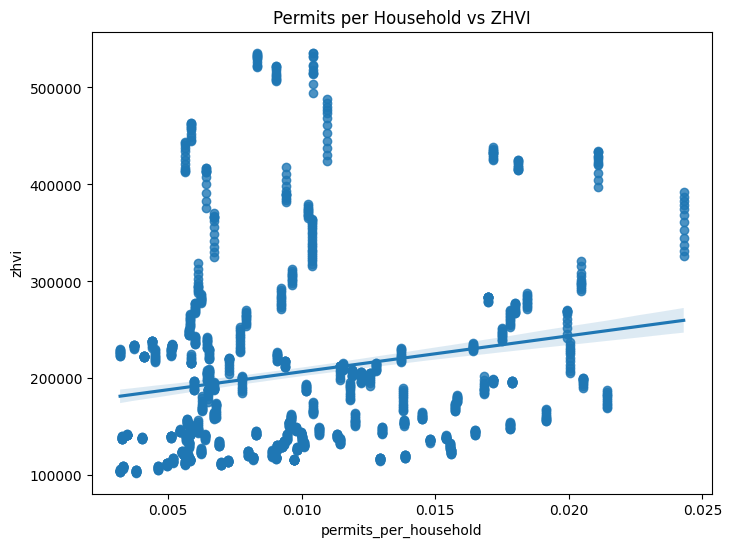

In [50]:
df = df.sort_values(["division", "date"])

# 2. Create lag feature (permits)
df["permits_lag1"] = df.groupby("division")["construction_permits"].shift(1)

# 3. Normalize permits
df["permits_per_household"] = df["construction_permits"] / df["total_households"]

# Drop missing values from lag
df_lag = df.dropna(subset=["permits_lag1"])


# 6. Separate by region (cleaner insight)
sns.lmplot(
    x="construction_permits",
    y="zhvi",
    hue="division",
    data=df,
    height=6,
    aspect=1.5
)
plt.title("Construction Permits vs ZHVI by Division")
plt.show()

# 7. Permits per Household (construction permits / total households)
plt.figure(figsize=(8,6))
sns.regplot(x="permits_per_household", y="zhvi", data=df)
plt.title("Permits per Household vs ZHVI")
plt.show()


**Construction Permits vs ZHVI by Division**
When disaggregated by division, the relationship between construction permits and ZHVI becomes much clearer, with each region showing a positive trend. This suggests that construction activity scales with housing demand within regions. However, the differences in slopes and levels across divisions highlight strong regional heterogeneity, indicating that housing dynamics vary significantly by geographic area.
**Permits per Household vs ZHVI**
When normalizing permits by the number of households, the relationship becomes weak and noisy, suggesting that relative supply alone does not significantly drive housing prices. This indicates that housing markets are primarily demand-driven, with supply responding to, rather than controlling, price levels.

When disaggregated by division, the relationship between construction permits and ZHVI becomes much clearer, with each region showing a positive trend. This suggests that construction activity scales with housing demand within regions. However, the differences in slopes and levels across divisions highlight strong regional heterogeneity, indicating that housing dynamics vary significantly by geographic area.

# Affordability Analysis
ZHVI / Median Income to show Housing Affordability over Time

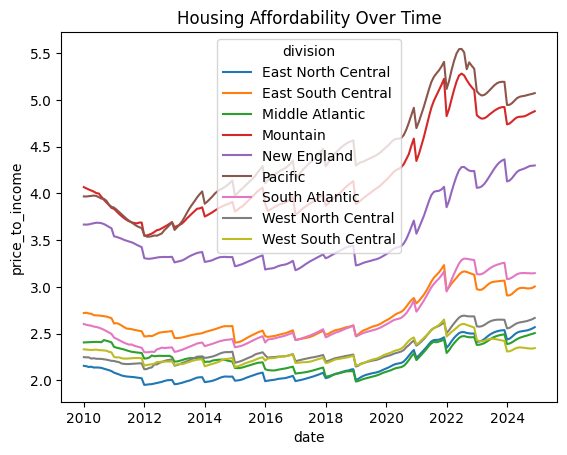

In [51]:
df["price_to_income"] = df["zhvi"] / df["median_income"]

sns.lineplot(data=df, x="date", y="price_to_income", hue="division")
plt.title("Housing Affordability Over Time")
plt.show()

The price-to-income ratio shows a clear decline in housing affordability across all U.S. divisions over time, with a sharp acceleration after 2020. This indicates that home prices have grown significantly faster than incomes, particularly during the pandemic period. The Pacific and Mountain regions exhibit the highest levels of unaffordability, while Midwest and South Central regions remain relatively more affordable. However, the widening gap between regions suggests increasing geographic inequality in housing affordability. Overall, the results highlight a nationwide affordability crisis driven by rising home prices outpacing income growth.

## Education vs Housing Prices

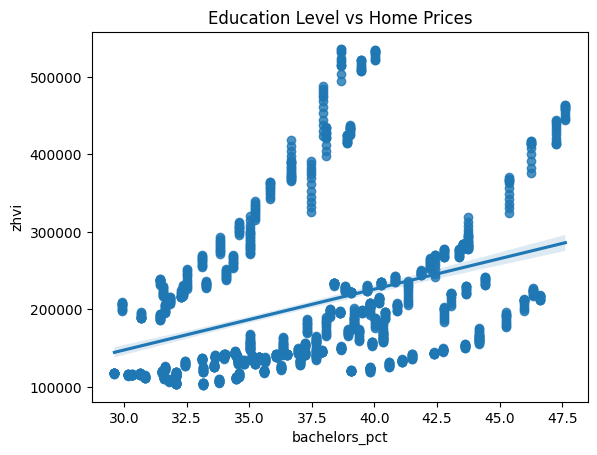

In [52]:
sns.regplot(x="bachelors_pct", y="zhvi", data=df)
plt.title("Education Level vs Home Prices")
plt.show()

## Unemployment vs Housing Prices

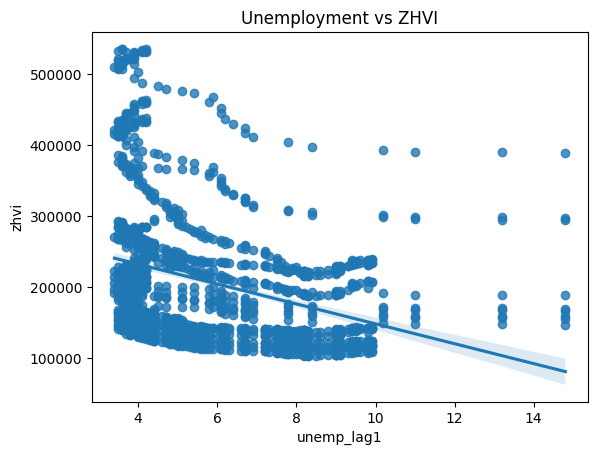

In [53]:
df["unemp_lag1"] = df.groupby("division")["unemployment_rate"].shift(1)
sns.regplot(x="unemp_lag1", y="zhvi", data=df)
plt.title("Unemployment vs ZHVI")
plt.show()

The plot between unemployment and ZVI shows a clear negative relationship. It suggest that as unemployment increases, ZHVI decreases. Higher inemployment weakens housing demand, leading to lower house pices. The relationship is real but not strong suggesting that it may affect housing prices but it isn't the primary driver.

Regional Comparison

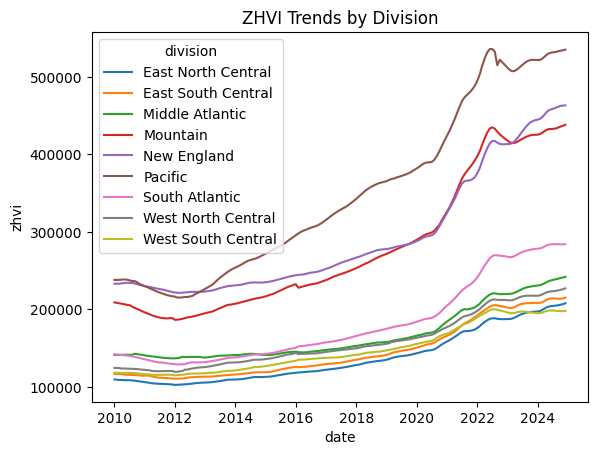

In [54]:
sns.lineplot(data=df, x="date", y="zhvi", hue="division")
plt.title("ZHVI Trends by Division")
plt.show()

The time-series analysis of ZHVI across U.S. divisions reveals a consistent upward trend in housing prices with a pronounced acceleration after 2020. This surge appears across all regions, suggesting a nationwide demand shock likely driven by macroeconomic factors such as low interest rates and pandemic-related housing shifts. However, significant regional disparities shows with Pacific division maintaining the highest price levels and widening the gap relative to lower-cost regions such as the East North Central and West South Central divisions. This indicates that while housing prices are rising broadly, regional inequality in housing markets is increasing over time.

Correlation Heatmap

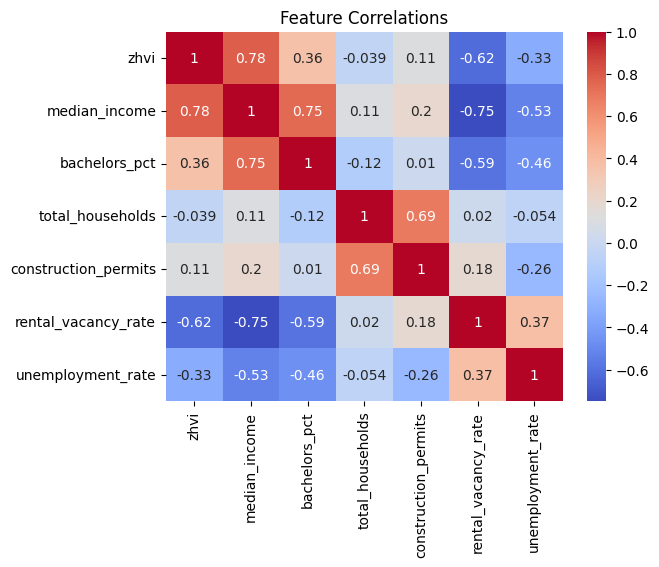

In [55]:
cols = [
    "zhvi", "median_income", "bachelors_pct",
    "total_households", "construction_permits",
    "rental_vacancy_rate", "unemployment_rate"
]

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

This heat map shows us that the strongest driver of ZHVI is median income. The correlation with ZHVI is 0.78 which is a very strong postive relationship. Areas with higher income tend to have significantly higher home values.
Education is indirectly important as education impacts housing prices through income not directly, showing multicollinearity.
Rental Vacancy rate has a strong negative effect with -0.62 which shows the supply/demand imbalance when there are more empty housing.
Unemployment negatiely affects housing (-0.33) implying higher unemployment shows weaker demand and lower prices.
Construction permits isn't directly related but construction permits per houshold shows a strong relation (0.69) showing that permits scale with region size not price.
Total households isn't a price drive (0) showing that market size alone doesn't determine the house prices.